In [55]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math

In [56]:
lista_aleatoria = [random.randint(1, 1000) for _ in range(100)]

In [57]:

lista_2 = lista_aleatoria[:2]

lista_4 = lista_aleatoria[:4]

lista_8 = lista_aleatoria[:8]

lista_16 = lista_aleatoria[:16]

lista_32 = lista_aleatoria[:32]
    
lista_64 = lista_aleatoria[:64]

In [58]:
media_2 = sum(lista_2) / len(lista_2)
media_4 = sum(lista_4) / len(lista_4)
media_8 = sum(lista_8) / len(lista_8)
media_16 = sum(lista_16) / len(lista_16)
media_32 = sum(lista_32) / len(lista_32)
media_64 = sum(lista_64) / len(lista_64)

In [59]:
#desvios acumulados (chamei de y)
def calcular_Y(lista):
    media = sum(lista) / len(lista)
    y = []
    soma_aux = 0
    for x in lista:
        soma_aux += (x - media)
        y.append(soma_aux)
    return y

#o y pra cada uma das listas
y_2 = calcular_Y(lista_2)
y_4 = calcular_Y(lista_4)
y_8 = calcular_Y(lista_8)
y_16 = calcular_Y(lista_16)
y_32 = calcular_Y(lista_32)
y_64 = calcular_Y(lista_64)


In [60]:
#(Range)
def calcular_R(y):
    amplitude = max(y) - min(y)
    return amplitude

r_2 = calcular_R(y_2)
r_4 = calcular_R(y_4)
r_8 = calcular_R(y_8)
r_16 = calcular_R(y_16)
r_32 = calcular_R(y_32)
r_64 = calcular_R(y_64)

In [61]:
#desvio padrão
def calcular_S(lista):
    n = len(lista)
    media = sum(lista) / n
    
    soma_quadrados = sum([(x - media)**2 for x in lista])
    variancia = soma_quadrados / n
    desvio_padrao = variancia**0.5
    
    return desvio_padrao

s_2 = calcular_S(lista_2)
s_4 = calcular_S(lista_4)
s_8 = calcular_S(lista_8)
s_16 = calcular_S(lista_16)
s_32 = calcular_S(lista_32)
s_64 = calcular_S(lista_64)

In [62]:
def calcular_RS(lista_original, lista_y):
    R = max(lista_y) - min(lista_y)
    
    n = len(lista_original)
    media = sum(lista_original) / n
    soma_quadrados = sum((x - media)**2 for x in lista_original)
    S = (soma_quadrados / n)**0.5
    
    return R / S 

rs_2 = calcular_RS(lista_2, y_2)
rs_4 = calcular_RS(lista_4, y_4)
rs_8 = calcular_RS(lista_8, y_8)
rs_16 = calcular_RS(lista_16, y_16)
rs_32 = calcular_RS(lista_32, y_32)
rs_64 = calcular_RS(lista_64, y_64)

#lista com os rs ainda nao logaritmizados
lista_final_RS = [rs_2, rs_4, rs_8, rs_16, rs_32, rs_64]

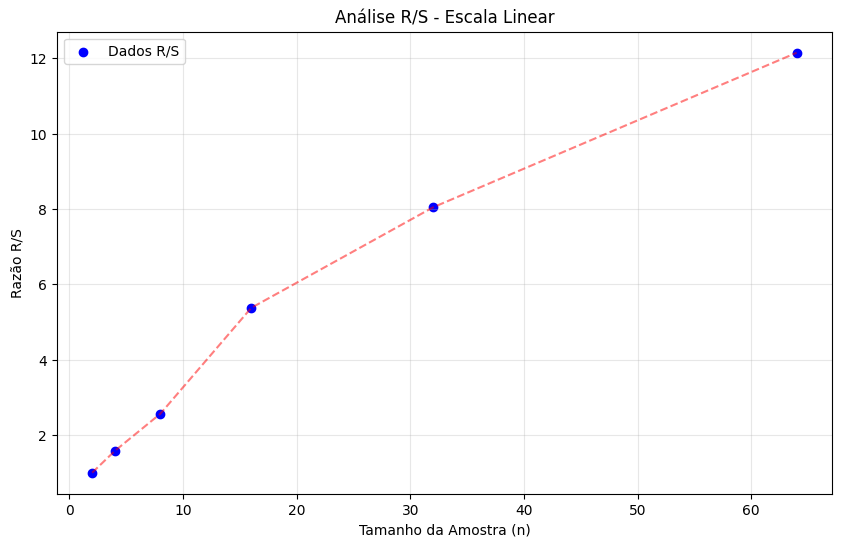

In [63]:
#usei o gpt, nao sei usar o matplotlib ainda

def plotar_rs(n_valores, rs_valores):
    # Cria o gráfico
    plt.figure(figsize=(10, 6))
    
    # Plota os pontos (n no eixo X, R/S no eixo Y)
    plt.scatter(n_valores, rs_valores, color='blue', label='Dados R/S')
    
    # Adiciona uma linha conectando os pontos para facilitar a visualização da tendência
    plt.plot(n_valores, rs_valores, color='red', linestyle='--', alpha=0.5)
    
    # Configurações de títulos e eixos
    plt.title('Análise R/S - Escala Linear')
    plt.xlabel('Tamanho da Amostra (n)')
    plt.ylabel('Razão R/S')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    
    # Exibe o gráfico
    plt.show()

n_valores = [2, 4, 8, 16, 32, 64]
plotar_rs(n_valores, lista_final_RS)

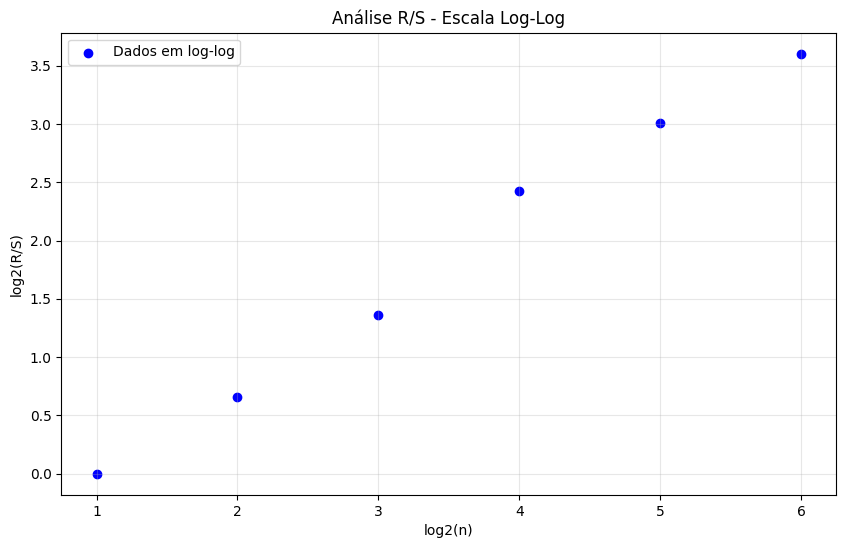

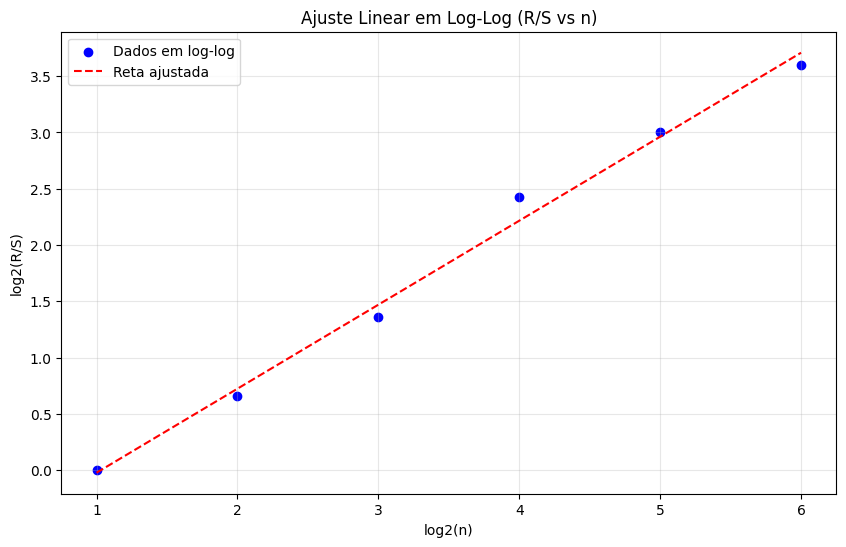

Parâmetros do ajuste em log-log:
Intercepto a = -0.7700742242337925
Inclinação  b = 0.7464529390318553


In [64]:
#usei o gpt pq ja tava putasso de nao ter entendido algumas coisas, so queria que essa porra me desse o resultado
def plotar_rs_loglog(n_valores, rs_valores, base="e"):
    n = np.array(n_valores, dtype=float)
    rs = np.array(rs_valores, dtype=float)

    mask = rs > 0
    n = n[mask]
    rs = rs[mask]

    if base == "2":
        x = np.log2(n)
        y = np.log2(rs)
        xlabel = "log2(n)"
        ylabel = "log2(R/S)"
    elif base == "10":
        x = np.log10(n)
        y = np.log10(rs)
        xlabel = "log10(n)"
        ylabel = "log10(R/S)"
    else:
        x = np.log(n)
        y = np.log(rs)
        xlabel = "ln(n)"
        ylabel = "ln(R/S)"

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color="blue", label="Dados em log-log")
    plt.title("Análise R/S - Escala Log-Log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    plt.show()

def ajustar_reta_loglog_e_plotar(n_valores, rs_valores, base="e"):
    n = np.array(n_valores, dtype=float)
    rs = np.array(rs_valores, dtype=float)

    mask = rs > 0
    n = n[mask]
    rs = rs[mask]

    if base == "2":
        x = np.log2(n)
        y = np.log2(rs)
        xlabel = "log2(n)"
        ylabel = "log2(R/S)"
    elif base == "10":
        x = np.log10(n)
        y = np.log10(rs)
        xlabel = "log10(n)"
        ylabel = "log10(R/S)"
    else:
        x = np.log(n)
        y = np.log(rs)
        xlabel = "ln(n)"
        ylabel = "ln(R/S)"

    # Ajuste linear: y ≈ a + b*x
    b, a = np.polyfit(x, y, 1)  # slope=b, intercept=a

    # Predição na mesma escala (log)
    y_hat = a + b * x

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color="blue", label="Dados em log-log")
    plt.plot(x, y_hat, color="red", linestyle="--", label="Reta ajustada")
    plt.title("Ajuste Linear em Log-Log (R/S vs n)")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    plt.show()

    # Retorna parâmetros para você usar depois
    return a, b


# Agora com base 2 de verdade:
plotar_rs_loglog(n_valores, lista_final_RS, base="2")

# Agora: reta ajustada em log-log + impressão dos parâmetros
a, b = ajustar_reta_loglog_e_plotar(n_valores, lista_final_RS, base="2")
print("Parâmetros do ajuste em log-log:")
print("Intercepto a =", a)
print("Inclinação  b =", b)

In [65]:
H = b
print("Expoente (H) =", H)

Expoente (H) = 0.7464529390318553
